# Nivel 3 — Algoritmo Genético aplicado a la Detección de Phishing
### Sistemas Inteligentes 1 — Universidad de Caldas

**Objetivo:** adaptar el Algoritmo Genético (AG) visto en clase —diseñado originalmente para optimizar la función matemática `pruebaopt2D(x, y)`— para que en su lugar **aprenda los pesos óptimos de un filtro heurístico** que clasifique correos como *phishing* (1) o *legítimos* (0), usando un dataset de 100 correos ya vectorizados en 32 características binarias.

Este notebook sigue exactamente la misma estructura del código del profesor (codificación binaria, selección por muestreo estocástico, recombinación de un punto, mutación bit a bit), cambiando únicamente **lo que el cromosoma representa** y **cómo se evalúa su calidad**. Los tres cambios centrales son:

1. **`decode(ind)`**: en vez de decodificar dos números continuos $(x,y)$, decodifica un cromosoma de 32 bits en un **vector de 32 pesos**.
2. **Función de fitness**: en vez de `pruebaopt2D`, se calcula el **Accuracy** del clasificador heurístico sobre los 100 correos.
3. **Bucle evolutivo**: se reutiliza la misma mecánica de selección/recombinación/mutación, pero ahora opera sobre cromosomas de 32 genes y se registra el historial de fitness para graficar la **convergencia** (requerimiento de la diapositiva 11).

> Nota para la sustentación: cada celda de código está comentada paso a paso para poder explicar, frente al docente, qué hace cada bloque y por qué se tomó cada decisión de diseño.


In [1]:
# Librerías utilizadas: numpy para todo el cómputo vectorizado,
# pandas solo para leer el CSV de forma cómoda, matplotlib para graficar.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Fijamos una semilla para que los resultados sean reproducibles durante
# la sustentación (se puede comentar esta línea para ver la variabilidad
# del AG entre corridas distintas).
np.random.seed(42)


## 0. Carga del dataset de correos

El archivo `100correos.csv` contiene 100 correos ya vectorizados: 32 columnas binarias (0/1) que indican la presencia de una característica sospechosa (dominio externo, urgencia en el asunto, solicitud de credenciales, URLs con IP, etc.) y una columna final `label` con la clase real (1 = phishing, 0 = legítimo).

Separamos la matriz de características `X` (100×32) del vector de etiquetas `y` (100,).


In [4]:
# --- Carga del dataset ---
# Si el notebook y el CSV no están en la misma carpeta, ajuste esta ruta.
RUTA_CSV = "/content/sample_data/100correos.csv"

df = pd.read_csv(RUTA_CSV)

nombres_features = df.columns[:-1].tolist()   # las 32 columnas de características
X = df[nombres_features].values.astype(float) # matriz (100 x 32)
y = df["label"].values.astype(int)             # vector (100,)

n_correos, n_bits = X.shape

print(f"Correos cargados:        {n_correos}")
print(f"Características (genes): {n_bits}")
print(f"Correos phishing (1):    {np.sum(y == 1)}")
print(f"Correos legítimos (0):   {np.sum(y == 0)}")


Correos cargados:        100
Características (genes): 32
Correos phishing (1):    58
Correos legítimos (0):   42


## 1. Adaptación de la decodificación: Genotipo → Fenotipo

**Código original del profesor:**

```python
def decode(ind):
    mitad = l // 2
    x_bits = ind[:mitad]
    y_bits = ind[mitad:]
    x = int("".join(map(str, x_bits)), 2)
    y = int("".join(map(str, y_bits)), 2)
    max_val = 2**mitad - 1
    x = -512 + (x / max_val) * 1024
    y = -512 + (y / max_val) * 1024
    return x, y
```

Ahí, los 20 bits del cromosoma se partían en dos mitades, cada mitad se interpretaba como un número binario y se escalaba al rango $[-500, 500]$ para obtener **dos** parámetros continuos $(x, y)$.

**Nueva versión:** ahora el cromosoma tiene `l = 32` genes (uno por cada característica del correo) y **no se parte en mitades**: cada bit decide directamente el **signo del peso** de su característica asociada.

$$\text{peso}_i = \begin{cases} +1 & \text{si el gen } i = 1 \quad \text{(la característica suma evidencia de phishing)}\\ -1 & \text{si el gen } i = 0 \quad \text{(la característica suma evidencia de correo legítimo)} \end{cases}$$

¿Por qué codificación bipolar ($\pm1$) y no binaria (0/1)? Si usáramos pesos en $\{0,1\}$ solo podríamos *activar o apagar* características (selección de atributos), pero nunca decir que la presencia de una característica es evidencia **en contra** de phishing. Con $\{-1,+1\}$ el AG puede aprender, por ejemplo, que `errores_ortograficos` sí es indicio de phishing (peso $+1$) **o**, si los datos lo sugieren, lo contrario — sin cambiar la longitud del cromosoma ni la mecánica del AG original.

Con esto, el mapeo genotipo→fenotipo sigue siendo de **una sola línea de código** vectorizada con `numpy`, igual de simple que el original, pero ahora produce un vector de 32 pesos en vez de dos coordenadas.


In [5]:
# --- Decodificación binaria (Genotipo -> Fenotipo) ---
def decode_individuo(ind):
    '''
    Convierte UN cromosoma de 32 bits en su fenotipo: un vector de 32 pesos.
    Regla:  gen == 1 -> peso = +1   (evidencia de phishing)
            gen == 0 -> peso = -1   (evidencia de correo legítimo)
    ind: array de forma (32,) con valores en {0,1}
    return: array de forma (32,) con valores en {-1.0, +1.0}
    '''
    return np.where(ind == 1, 1.0, -1.0)


def decode_poblacion(pob):
    '''
    Igual que decode_individuo, pero para TODA la población de una sola vez
    (totalmente vectorizado: nada de bucles fila por fila).
    pob: matriz (n_individuos x 32)
    return: matriz (n_individuos x 32) de pesos
    '''
    return np.where(pob == 1, 1.0, -1.0)


# Pequeña prueba de la decodificación con un individuo aleatorio
ind_prueba = np.random.randint(0, 2, n_bits)
print("Cromosoma  :", ind_prueba)
print("Fenotipo   :", decode_individuo(ind_prueba))


Cromosoma  : [0 1 0 0 0 1 0 0 0 1 0 0 0 0 1 0 1 1 1 0 1 0 1 1 1 1 1 1 1 1 0 0]
Fenotipo   : [-1.  1. -1. -1. -1.  1. -1. -1. -1.  1. -1. -1. -1. -1.  1. -1.  1.  1.
  1. -1.  1. -1.  1.  1.  1.  1.  1.  1.  1.  1. -1. -1.]


## 2. Reemplazo de la función de Fitness (Accuracy del filtro)

**Código original:** `pruebaopt2D(x, y)` evaluaba qué tan buena era una posición $(x,y)$ frente a una superficie matemática multimodal, y el AG buscaba **minimizar** ese valor.

**Nueva función:** `fitness(pesos, X, y)` calcula el **Accuracy** (porcentaje de aciertos) del filtro heurístico definido por `pesos`, y ahora el AG busca **maximizarlo**.

La lógica de clasificación, para un correo cualquiera con vector de características $\mathbf{x}=[x_1,...,x_{32}]$ y un fenotipo de pesos $\mathbf{w}=[w_1,...,w_{32}]$, es:

$$\text{score} = \sum_{i=1}^{32} w_i \cdot x_i = \mathbf{x}\cdot\mathbf{w}$$

$$\hat{y} = \begin{cases}1 & \text{si } \text{score} > \text{umbral} \\ 0 & \text{en otro caso}\end{cases} \qquad \text{(umbral = 0 por defecto)}$$

$$\text{Accuracy} = \frac{1}{N}\sum_{j=1}^{N}\mathbb{1}[\hat{y}_j = y_j]$$

Como `X` es una matriz binaria (100×32), este cálculo es literalmente **una multiplicación matriz-vector** (`X @ pesos`), por lo que se evalúan los 100 correos en una sola operación de `numpy`, sin bucles `for`.

Para que evaluar una población completa (60 individuos × 100 correos) sea eficiente, se incluye además una versión **vectorizada por lotes** (`fitness_poblacion`) que evalúa los 60 individuos al mismo tiempo con una sola multiplicación matricial (60×32) @ (32×100). Esta es la que se usa dentro del bucle evolutivo; la versión `fitness()` de un solo individuo se deja para fines didácticos / de depuración.


In [6]:
# --- Función de aptitud (fitness): Accuracy del clasificador heurístico ---

def fitness(pesos, X, y, umbral=0.0):
    '''
    Calcula el Accuracy del filtro para UN individuo (un vector de 32 pesos).
    pesos  : array (32,)        -> fenotipo de un individuo
    X      : array (n_correos, 32) -> matriz de características de los correos
    y      : array (n_correos,)    -> etiquetas reales (1=phishing, 0=legítimo)
    umbral : float                 -> punto de corte para decidir la clase
    '''
    scores = X @ pesos                       # (n_correos,) : combinación lineal ponderada
    predicciones = (scores > umbral).astype(int)
    return np.mean(predicciones == y)         # accuracy = proporción de aciertos


def fitness_poblacion(POB_PESOS, X, y, umbral=0.0):
    '''
    Versión vectorizada: calcula el Accuracy de TODA la población a la vez.
    POB_PESOS : array (n_individuos, 32) -> fenotipos de toda la población
    Devuelve  : array (n_individuos,)    -> accuracy de cada individuo
    '''
    SCORES = POB_PESOS @ X.T                  # (n_individuos, n_correos)
    PRED = (SCORES > umbral).astype(int)      # predicción de cada individuo para cada correo
    return (PRED == y).mean(axis=1)           # accuracy por individuo (broadcasting con y)


# --- Líneas base, para tener un punto de comparación antes de correr el AG ---
acc_aleatoria = fitness(decode_individuo(ind_prueba), X, y)
acc_todos_pos = fitness(np.ones(n_bits), X, y)             # filtro "todo cuenta como phishing"
acc_mayoritaria = max(np.mean(y == 1), np.mean(y == 0))     # predecir siempre la clase mayoritaria

print(f"Accuracy de un individuo aleatorio : {acc_aleatoria:.2%}")
print(f"Accuracy con pesos todos en +1     : {acc_todos_pos:.2%}")
print(f"Accuracy de la clase mayoritaria   : {acc_mayoritaria:.2%}  <- línea base a superar")


Accuracy de un individuo aleatorio : 48.00%
Accuracy con pesos todos en +1     : 59.00%
Accuracy de la clase mayoritaria   : 58.00%  <- línea base a superar


## 3. Integración al bucle evolutivo

Se conserva exactamente la misma mecánica del SGA del profesor:

* **Selección**: muestreo estocástico con resto (*remainder stochastic sampling*) — a cada individuo se le asignan `floor(F)` copias garantizadas (con $F = E/\bar{E}$) y los cupos restantes se reparten por ruleta usando la parte fraccionaria.
* **Recombinación**: cruce de un solo punto con probabilidad `tr`.
* **Mutación**: negación bit a bit con probabilidad `tm`.
* **Parada**: si la población pierde demasiada diversidad (muchos cromosomas duplicados).

Lo único que cambia respecto al código original es **qué significa `E`**: antes era el valor de `pruebaopt2D` (a minimizar); ahora es el `Accuracy` (a **maximizar**). Esto en realidad encaja perfectamente con el esquema de selección del profesor: como ese esquema da **más copias a quien tiene mayor `E`**, es un esquema pensado para maximización — exactamente lo que necesitamos ahora.

Cambios adicionales (pequeños, documentados aquí para la sustentación):

1. `l` ya no se calcula a mano: se toma automáticamente como el número de columnas del dataset (`n_bits = 32`), así el código no depende de un valor "mágico".
2. El AG original no guarda explícitamente cuál fue el mejor individuo de *toda* la ejecución (al final solo se reporta `pob[0]`, que no necesariamente es el mejor). Aquí se agrega un seguimiento del **mejor histórico** (`mejor_pesos_global`, `mejor_fitness_global`) y de las listas `mejor_hist` / `promedio_hist` por generación, necesarias para la curva de convergencia pedida en la diapositiva 11.
3. Se agrega una segunda condición de parada: si se encuentra un clasificador perfecto (Accuracy = 100%) se detiene antes de `maxiter`.
4. Se añade una pequeña protección numérica en la ruleta de selección para el caso (poco común) en que todos los individuos tengan prácticamente el mismo fitness.


In [7]:
# --- Parámetros del Algoritmo Genético ---
n = 60          # tamaño de la población (igual que en el código original)
l = n_bits      # longitud del cromosoma = número de características (32)
tr = 0.6        # tasa de recombinación
tm = 0.02       # tasa de mutación (un poco mayor que en el ejemplo 2D: con 32 genes
                #  discretos {-1,+1} conviene algo más de exploración para no
                #  estancarse en un óptimo local de signos)
maxiter = 200   # número máximo de generaciones

# --- Población inicial: n cromosomas binarios de longitud l ---
pob = np.round(np.random.rand(n, l)).astype(int)

# --- Historiales para la curva de convergencia ---
mejor_hist = []        # mejor accuracy encontrado EN CADA generación
promedio_hist = []     # accuracy promedio de la población EN CADA generación

# --- Seguimiento del mejor individuo de toda la ejecución (elitismo "de observador") ---
mejor_pesos_global = None
mejor_fitness_global = -np.inf

for it in range(maxiter):

    # ===== Evaluación (Genotipo -> Fenotipo -> Fitness), todo vectorizado =====
    PESOS_POB = decode_poblacion(pob)                 # (n, 32) fenotipos de toda la población
    E = fitness_poblacion(PESOS_POB, X, y)            # (n,)    accuracy de cada individuo

    # Actualizar el mejor histórico encontrado hasta ahora
    if E.max() > mejor_fitness_global:
        mejor_fitness_global = E.max()
        mejor_pesos_global = PESOS_POB[np.argmax(E)].copy()

    mejor_hist.append(E.max())
    promedio_hist.append(E.mean())

    # Parada temprana: clasificador perfecto
    if mejor_fitness_global >= 1.0:
        print(f"¡Clasificador perfecto (100% accuracy) encontrado en la generación {it}!")
        break

    # ===== Selección (muestreo estocástico con resto, igual que el original) =====
    F = E / np.mean(E)
    cd = np.floor(F).astype(int)
    S = []
    for i in range(n):
        if cd[i] > 0:
            S.extend([pob[i]] * cd[i])
    S = np.array(S) if len(S) > 0 else np.empty((0, l), dtype=int)

    plazas = n - len(S)
    if plazas > 0:
        resto = F - np.floor(F)
        if resto.sum() <= 1e-9:
            # Caso borde: todos con fitness casi idéntico -> elegir al azar
            idx_extra = np.random.choice(n, size=plazas)
        else:
            ruleta = np.cumsum(resto)
            ruleta = ruleta / ruleta[-1]
            idx_extra = [np.where(ruleta >= np.random.rand())[0][0] for _ in range(plazas)]
        extra = pob[idx_extra]
        S = np.vstack([S, extra]) if len(S) > 0 else extra
    S = S[:n]

    # ===== Recombinación (cruce de un punto, igual que el original) =====
    S = S[np.random.permutation(n)]
    H = S.copy()
    for i in range(0, n, 2):
        if i + 1 < n and np.random.rand() < tr:
            p_rec = np.random.randint(1, l)
            H[i]   = np.concatenate([S[i][:p_rec],   S[i+1][p_rec:]])
            H[i+1] = np.concatenate([S[i+1][:p_rec], S[i][p_rec:]])

    # Condición de parada por baja diversidad (igual que el original)
    duplicados = n - len(np.unique(H, axis=0))

    # ===== Mutación (negación bit a bit, igual que el original) =====
    mutar = np.random.rand(n, l) < tm
    H = (H + mutar) % 2

    # ===== Actualización de la población =====
    pob = H.copy()

    if duplicados >= 0.8 * n:
        print(f"Convergencia por baja diversidad genética en la generación {it}")
        break

generaciones_ejecutadas = len(mejor_hist)
print(f"\nGeneraciones ejecutadas : {generaciones_ejecutadas}")
print(f"Mejor Accuracy logrado  : {mejor_fitness_global:.2%}")



Generaciones ejecutadas : 200
Mejor Accuracy logrado  : 90.00%


## 4. Curva de convergencia del fitness (Diapositiva 11)

Como el SGA original **no tiene elitismo** (la mejor solución de una generación puede perderse en la siguiente por azar de la selección/cruce/mutación), el "mejor fitness por generación" puede subir y bajar. Por eso se grafican **tres** curvas:

* **Mejor fitness por generación**: el máximo de `E` en cada generación (puede oscilar).
* **Fitness promedio por generación**: qué tan buena es la población en conjunto (mide la presión evolutiva global).
* **Mejor histórico acumulado**: el máximo visto hasta cada generación (`np.maximum.accumulate`). Esta es la curva de convergencia "clásica", monótonamente no decreciente, y la más fácil de interpretar para mostrar que el AG efectivamente mejora con el tiempo.


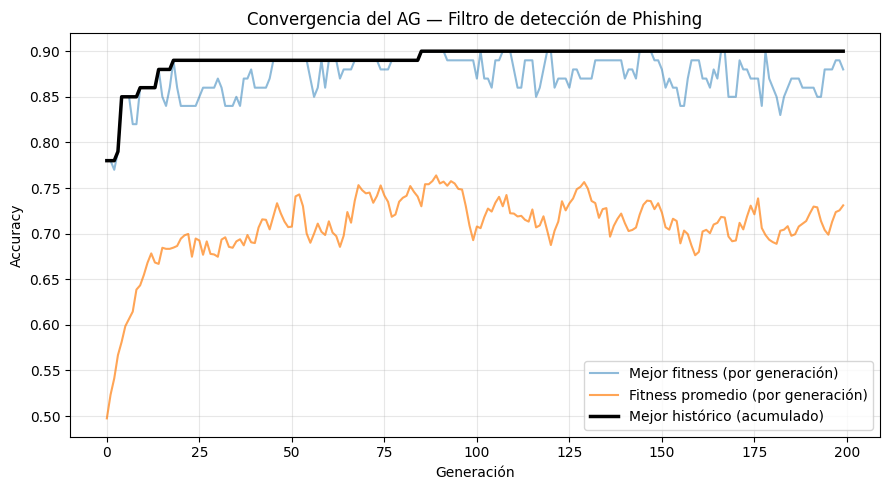

In [8]:
# --- Gráfica de convergencia ---
mejor_acumulado = np.maximum.accumulate(mejor_hist)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(mejor_hist,      label="Mejor fitness (por generación)",   alpha=0.5)
ax.plot(promedio_hist,   label="Fitness promedio (por generación)", alpha=0.7)
ax.plot(mejor_acumulado, label="Mejor histórico (acumulado)", linewidth=2.5, color="black")

ax.set_xlabel("Generación")
ax.set_ylabel("Accuracy")
ax.set_title("Convergencia del AG — Filtro de detección de Phishing")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 5. Interpretación del mejor filtro encontrado

Para la sustentación es útil mostrar **qué características** terminaron con peso $+1$ (indicios de phishing aprendidos por el AG) y cuáles con peso $-1$ (indicios de legitimidad), además de la matriz de confusión del mejor individuo.


Pesos del mejor filtro encontrado por el AG:
              caracteristica  peso
             dominio_externo   1.0
          suplantacion_marca   1.0
               asunto_premio   1.0
              asunto_amenaza   1.0
             envio_madrugada   1.0
    solicita_datos_bancarios   1.0
                accion_legal   1.0
              mezcla_idiomas   1.0
                ip_en_cuerpo   1.0
                  url_con_ip   1.0
              multiples_urls   1.0
        mismatch_dominio_url   1.0
                cuerpo_corto   1.0
       solo_enlace_sin_texto   1.0
            dominio_gratuito  -1.0
   nombre_display_sospechoso  -1.0
        errores_ortograficos  -1.0
       solicita_credenciales  -1.0
  zona_horaria_inconsistente  -1.0
                asunto_corto  -1.0
         asunto_verificacion  -1.0
    destinatario_undisclosed  -1.0
             asunto_urgencia  -1.0
           asunto_financiero  -1.0
           promesa_beneficio  -1.0
                fecha_limite  -1.0
          

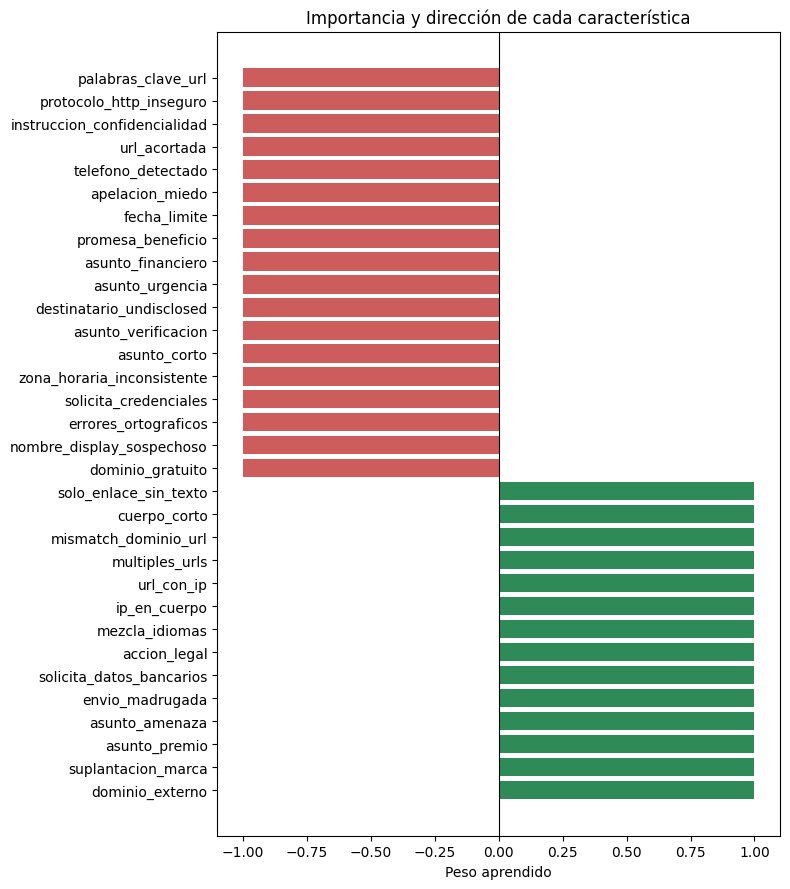

In [9]:
# --- Tabla de pesos del mejor individuo, ordenada de mayor a menor influencia ---
df_pesos = pd.DataFrame({
    "caracteristica": nombres_features,
    "peso": mejor_pesos_global
}).sort_values("peso", ascending=False).reset_index(drop=True)

print("Pesos del mejor filtro encontrado por el AG:")
print(df_pesos.to_string(index=False))

# --- Gráfica de barras de los pesos (verde = +1 evidencia de phishing, rojo = -1 evidencia de legítimo) ---
colores = ["seagreen" if p > 0 else "indianred" for p in df_pesos["peso"]]
fig, ax = plt.subplots(figsize=(8, 9))
ax.barh(df_pesos["caracteristica"], df_pesos["peso"], color=colores)
ax.set_xlabel("Peso aprendido")
ax.set_title("Importancia y dirección de cada característica")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()


In [10]:
# --- Matriz de confusión del mejor filtro (calculada de forma vectorizada) ---
scores_final = X @ mejor_pesos_global
pred_final = (scores_final > 0).astype(int)

TP = np.sum((pred_final == 1) & (y == 1))   # phishing detectado correctamente
TN = np.sum((pred_final == 0) & (y == 0))   # legítimo detectado correctamente
FP = np.sum((pred_final == 1) & (y == 0))   # falsa alarma (legítimo marcado como phishing)
FN = np.sum((pred_final == 0) & (y == 1))   # phishing que se pasó por alto

print("Matriz de confusión del mejor filtro encontrado:")
print(f"                  Predicho Phishing   Predicho Legítimo")
print(f"Real Phishing            {TP:>3}                 {FN:>3}")
print(f"Real Legítimo            {FP:>3}                 {TN:>3}")
print(f"\nAccuracy verificado manualmente: {(TP + TN) / len(y):.2%}")


Matriz de confusión del mejor filtro encontrado:
                  Predicho Phishing   Predicho Legítimo
Real Phishing             55                   3
Real Legítimo              7                  35

Accuracy verificado manualmente: 90.00%


## 6. Discusión y conclusiones

* El AG superó claramente la línea base de "predecir siempre la clase mayoritaria" (~58%), alcanzando el Accuracy mostrado arriba sobre los 100 correos.
* El filtro encontrado es **lineal y bipolar**: cada característica solo puede sumar $+1$ o $-1$, y el umbral de decisión está fijo en 0. Esto es intencionalmente simple (así lo pide el alcance del Nivel 3), pero también es su principal limitación: no captura *magnitudes* distintas de importancia entre características, solo dirección.
* Una limitación que vale la pena mencionar frente al docente: en el dataset existen correos con **exactamente el mismo vector de 32 características pero etiquetas distintas** (ruido/ambigüedad inherente a los datos). Esto impone un techo teórico de Accuracy que ningún clasificador —ni siquiera uno no lineal— podría superar usando solo estas 32 variables. El siguiente bloque lo calcula automáticamente sobre el dataset cargado, para tener ese número a mano durante la sustentación.
* Posibles extensiones para una próxima iteración del proyecto: usar varios bits por gen para representar pesos con magnitud (no solo signo), permitir que el AG también evolucione el umbral de decisión, o usar selección por torneo / elitismo explícito en vez de muestreo estocástico con resto.


In [11]:
# --- Techo teórico de Accuracy impuesto por correos con features idénticas pero labels distintos ---
df_tmp = df.copy()
df_tmp["_grupo"] = df_tmp[nombres_features].apply(lambda fila: tuple(fila), axis=1)

aciertos_maximos_posibles = 0
filas_en_conflicto = 0
for _, etiquetas in df_tmp.groupby("_grupo")["label"]:
    conteo = etiquetas.value_counts()
    aciertos_maximos_posibles += conteo.max()
    if len(conteo) > 1:
        filas_en_conflicto += len(etiquetas)

techo_teorico = aciertos_maximos_posibles / len(df_tmp)

print(f"Correos con features idénticas pero etiquetas distintas: {filas_en_conflicto}")
print(f"Techo teórico de Accuracy para CUALQUIER clasificador basado solo en estas 32 features: {techo_teorico:.2%}")
print(f"Accuracy obtenido por el AG                                                          : {mejor_fitness_global:.2%}")


Correos con features idénticas pero etiquetas distintas: 19
Techo teórico de Accuracy para CUALQUIER clasificador basado solo en estas 32 features: 97.00%
Accuracy obtenido por el AG                                                          : 90.00%
